In [ ]:
!pip install missingno -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import re
import warnings

# Tambahan untuk upload file dari Google Drive
from google.colab import drive

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

# Tambahan untuk EDA Visualisasi
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']
print(" Setup selesai!")

 Setup selesai!


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Contoh membaca file dari Google Drive
# Ganti sesuai lokasi file kamu
df = pd.read_csv('/content/drive/MyDrive/Capstone/Retail_Transactions_Dataset.csv')

# Menampilkan 5 data pertama
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'Potatoes']",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


In [ ]:
df_raw   = df.copy()
df_clean = df.copy()

print(f"Dataset siap.")
print(f"   Jumlah baris  : {len(df_raw):,}")
print(f"   Jumlah kolom  : {df_raw.shape[1]}")
display(df_raw.head())

Dataset siap.
   Jumlah baris  : 1,000,000
   Jumlah kolom  : 13


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'Potatoes']",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


# Assessing: Info & Statistik

In [ ]:
print("=" * 60)
print("ASSESSING DATA — GAMBARAN UMUM")
print("=" * 60)

print("\n── Tipe Data & Non-Null Count ──")
df_clean.info()

print("\n── Statistik Deskriptif (Numerik) ──")
display(df_clean.describe())

print("\n── Statistik Deskriptif (Kategorik) ──")
display(df_clean.describe(include='object'))

ASSESSING DATA — GAMBARAN UMUM

── Tipe Data & Non-Null Count ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  object 
 2   Customer_Name      1000000 non-null  object 
 3   Product            1000000 non-null  object 
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  object 
 7   City               1000000 non-null  object 
 8   Store_Type         1000000 non-null  object 
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  object 
 11  Season             1000000 non-null  object 
 12  Promotion          666057 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(9)
memory usage: 92.5+ MB



,Transaction_ID,Total_Items,Total_Cost
count,1000000.00,1000000.00,1000000.00
mean,1000499999.50,5.50,52.46
std,288675.28,2.87,27.42
min,1000000000.00,1.00,5.00
25%,1000249999.75,3.00,28.71
50%,1000499999.50,5.00,52.42
75%,1000749999.25,8.00,76.19
max,1000999999.00,10.00,100.00



── Statistik Deskriptif (Kategorik) ──


,Date,Customer_Name,Product,Payment_Method,City,Store_Type,Customer_Category,Season,Promotion
count,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,666057
unique,996337,329738,571947,4,10,6,8,4,2
top,2020-02-11 14:47:13,Michael Smith,['Toothpaste'],Cash,Boston,Supermarket,Senior Citizen,Spring,Discount on Selected Items
freq,3,454,4893,250230,100566,166936,125485,250368,333370


# Assessing: Quality Issues

In [ ]:
print("=" * 60)
print("ASSESSING DATA — QUALITY ISSUES")
print("=" * 60)

issues = []

# QI-1: Missing Values
missing     = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_df  = pd.DataFrame({'jumlah_null': missing, 'persentase_%': missing_pct})
missing_df  = missing_df[missing_df['jumlah_null'] > 0]

print("\n[QI-1] Missing Values:")
display(missing_df)
issues.append(f"QI-1 | Kolom 'Promotion' memiliki {missing['Promotion']:,} nilai null ({missing_pct['Promotion']:.1f}%)")

# QI-2: Tipe Data
print("\n[QI-2] Tipe Data:")
print(df_clean.dtypes.to_string())
print("\n  → Kolom 'Date' masih bertipe object, perlu dikonversi ke datetime.")
issues.append("QI-2 | Kolom 'Date' (object) perlu dikonversi ke datetime.")

# QI-3: Duplikat
n_dup = df_clean.duplicated().sum()
n_dup_id = df_clean['Transaction_ID'].duplicated().sum()
print(f"\n[QI-3] Duplikat:")
print(f"  Baris duplikat      : {n_dup:,}")
print(f"  Transaction_ID ganda: {n_dup_id:,}")
if n_dup == 0:
    print(" Tidak ada duplikat.")
else:
    issues.append(f"QI-3 | {n_dup} baris duplikat ditemukan.")

# QI-4: Inkonsistensi Season
df_tmp = df_clean.copy()
df_tmp['Date_dt'] = pd.to_datetime(df_tmp['Date'])
df_tmp['month']   = df_tmp['Date_dt'].dt.month

def month_to_season(m):
    if m in [12,1,2]: return 'Winter'
    if m in [3,4,5]:  return 'Spring'
    if m in [6,7,8]:  return 'Summer'
    return 'Fall'

df_tmp['expected_season'] = df_tmp['month'].apply(month_to_season)
season_mismatch = df_tmp[df_tmp['Season'] != df_tmp['expected_season']]
pct = len(season_mismatch) / len(df_clean) * 100

print(f"\n[QI-4] Inkonsistensi Season vs Tanggal:")
print(f"  Tidak sesuai: {len(season_mismatch):,} baris ({pct:.1f}%)")
display(season_mismatch[['Date','Season','expected_season']].head(5))
issues.append(f"QI-4 | {len(season_mismatch):,} baris ({pct:.1f}%) Season tidak sesuai tanggal.")

# QI-5: Total_Items vs Produk Aktual
def count_items(product_str):
    try:
        return len(ast.literal_eval(product_str))
    except:
        return np.nan

df_sample = df_clean.sample(5000, random_state=42).copy()
df_sample['actual_count'] = df_sample['Product'].apply(count_items)
items_mismatch = df_sample[df_sample['actual_count'] != df_sample['Total_Items']]
pct_items = len(items_mismatch) / len(df_sample) * 100

print(f"\n[QI-5] Total_Items vs Jumlah Produk Aktual (sample 5.000):")
print(f"  Tidak sesuai: {len(items_mismatch):,} baris ({pct_items:.1f}%)")
display(items_mismatch[['Total_Items','actual_count','Product']].head(5))
issues.append(f"QI-5 | {pct_items:.1f}% Total_Items tidak sesuai jumlah produk aktual.")

# QI-6: Outlier Total_Cost
q1  = df_clean['Total_Cost'].quantile(0.25)
q3  = df_clean['Total_Cost'].quantile(0.75)
iqr = q3 - q1
lower = max(q1 - 1.5*iqr, 0)
upper = q3 + 1.5*iqr
out_low  = (df_clean['Total_Cost'] < lower).sum()
out_high = (df_clean['Total_Cost'] > upper).sum()

print(f"\n[QI-6] Outlier Total_Cost (IQR):")
print(f"  Batas bawah: ${lower:.2f} | Batas atas: ${upper:.2f}")
print(f"  Outlier rendah : {out_low:,} | Outlier tinggi: {out_high:,}")
issues.append(f"QI-6 | Outlier Total_Cost: {out_low+out_high:,} baris di luar batas IQR.")

# QI-7: Format Product
print(f"\n[QI-7] Format Kolom 'Product':")
print(f"  Contoh: {df_clean['Product'].iloc[0]}")
print("  → Berupa string repr list Python, bukan list sesungguhnya.")
issues.append("QI-7 | Kolom 'Product' berupa string, perlu dikonversi ke list.")

print("\n" + "=" * 60)
print("RINGKASAN QUALITY ISSUES")
print("=" * 60)
for i, isu in enumerate(issues, 1):
    print(f"  {i}. {isu}")

ASSESSING DATA — QUALITY ISSUES

[QI-1] Missing Values:


,jumlah_null,persentase_%
Promotion,333943,33.39



[QI-2] Tipe Data:
Transaction_ID         int64
Date                  object
Customer_Name         object
Product               object
Total_Items            int64
Total_Cost           float64
Payment_Method        object
City                  object
Store_Type            object
Discount_Applied        bool
Customer_Category     object
Season                object
Promotion             object

  → Kolom 'Date' masih bertipe object, perlu dikonversi ke datetime.

[QI-3] Duplikat:
  Baris duplikat      : 0
  Transaction_ID ganda: 0
 Tidak ada duplikat.

[QI-4] Inkonsistensi Season vs Tanggal:
  Tidak sesuai: 750,358 baris (75.0%)


,Date,Season,expected_season
1,2023-03-01 13:01:21,Fall,Spring
2,2024-03-21 15:37:04,Winter,Spring
3,2020-10-31 09:59:47,Spring,Fall
5,2021-10-07 12:37:26,Spring,Fall
6,2023-01-08 10:40:03,Summer,Winter



[QI-5] Total_Items vs Jumlah Produk Aktual (sample 5.000):
  Tidak sesuai: 4,536 baris (90.7%)


,Total_Items,actual_count,Product
79954,5,1,['Cleaning Spray']
567130,9,5,"['Salmon', 'Garden Hose', 'Deodorant', 'Air Freshener', ..."
500891,5,2,"['Power Strips', 'Tuna']"
55399,6,5,"['Cereal', 'Cheese', 'Yogurt', 'Sponges', 'Chicken']"
733378,6,2,"['Pancake Mix', 'Cheese']"



[QI-6] Outlier Total_Cost (IQR):
  Batas bawah: $0.00 | Batas atas: $147.41
  Outlier rendah : 0 | Outlier tinggi: 0

[QI-7] Format Kolom 'Product':
  Contoh: ['Ketchup', 'Shaving Cream', 'Light Bulbs']
  → Berupa string repr list Python, bukan list sesungguhnya.

RINGKASAN QUALITY ISSUES
  1. QI-1 | Kolom 'Promotion' memiliki 333,943 nilai null (33.4%)
  2. QI-2 | Kolom 'Date' (object) perlu dikonversi ke datetime.
  3. QI-4 | 750,358 baris (75.0%) Season tidak sesuai tanggal.
  4. QI-5 | 90.7% Total_Items tidak sesuai jumlah produk aktual.
  5. QI-6 | Outlier Total_Cost: 0 baris di luar batas IQR.
  6. QI-7 | Kolom 'Product' berupa string, perlu dikonversi ke list.


# Assessing: Tidiness Issues

In [ ]:
print("=" * 60)
print("ASSESSING DATA — TIDINESS ISSUES")
print("=" * 60)

tidiness_issues = []

print("\n[TI-1] Kolom 'Product' multivalued (banyak item dalam 1 sel):")
display(df_clean[['Transaction_ID','Product']].head(4))
tidiness_issues.append("TI-1 | Kolom 'Product' multivalued — perlu di-explode.")

print("\n[TI-2] Kolom 'Date' gabungkan tanggal + jam dalam 1 kolom:")
print(f"  Contoh: '{df_clean['Date'].iloc[0]}'")
tidiness_issues.append("TI-2 | Kolom 'Date' perlu diekstrak jadi Year/Month/Day/Hour.")

print("\n[TI-3] Kolom 'Season' redundan dengan 'Date' dan 75% tidak konsisten.")
tidiness_issues.append("TI-3 | Kolom 'Season' redundan — akan dihapus.")

for i, ti in enumerate(tidiness_issues, 1):
    print(f"\n  {i}. {ti}")

ASSESSING DATA — TIDINESS ISSUES

[TI-1] Kolom 'Product' multivalued (banyak item dalam 1 sel):


,Transaction_ID,Product
0,1000000000,"['Ketchup', 'Shaving Cream', 'Light Bulbs']"
1,1000000001,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'Potatoes']"
2,1000000002,['Spinach']
3,1000000003,"['Tissues', 'Mustard']"



[TI-2] Kolom 'Date' gabungkan tanggal + jam dalam 1 kolom:
  Contoh: '2022-01-21 06:27:29'

[TI-3] Kolom 'Season' redundan dengan 'Date' dan 75% tidak konsisten.

  1. TI-1 | Kolom 'Product' multivalued — perlu di-explode.

  2. TI-2 | Kolom 'Date' perlu diekstrak jadi Year/Month/Day/Hour.

  3. TI-3 | Kolom 'Season' redundan — akan dihapus.


# Visualisasi Assessing

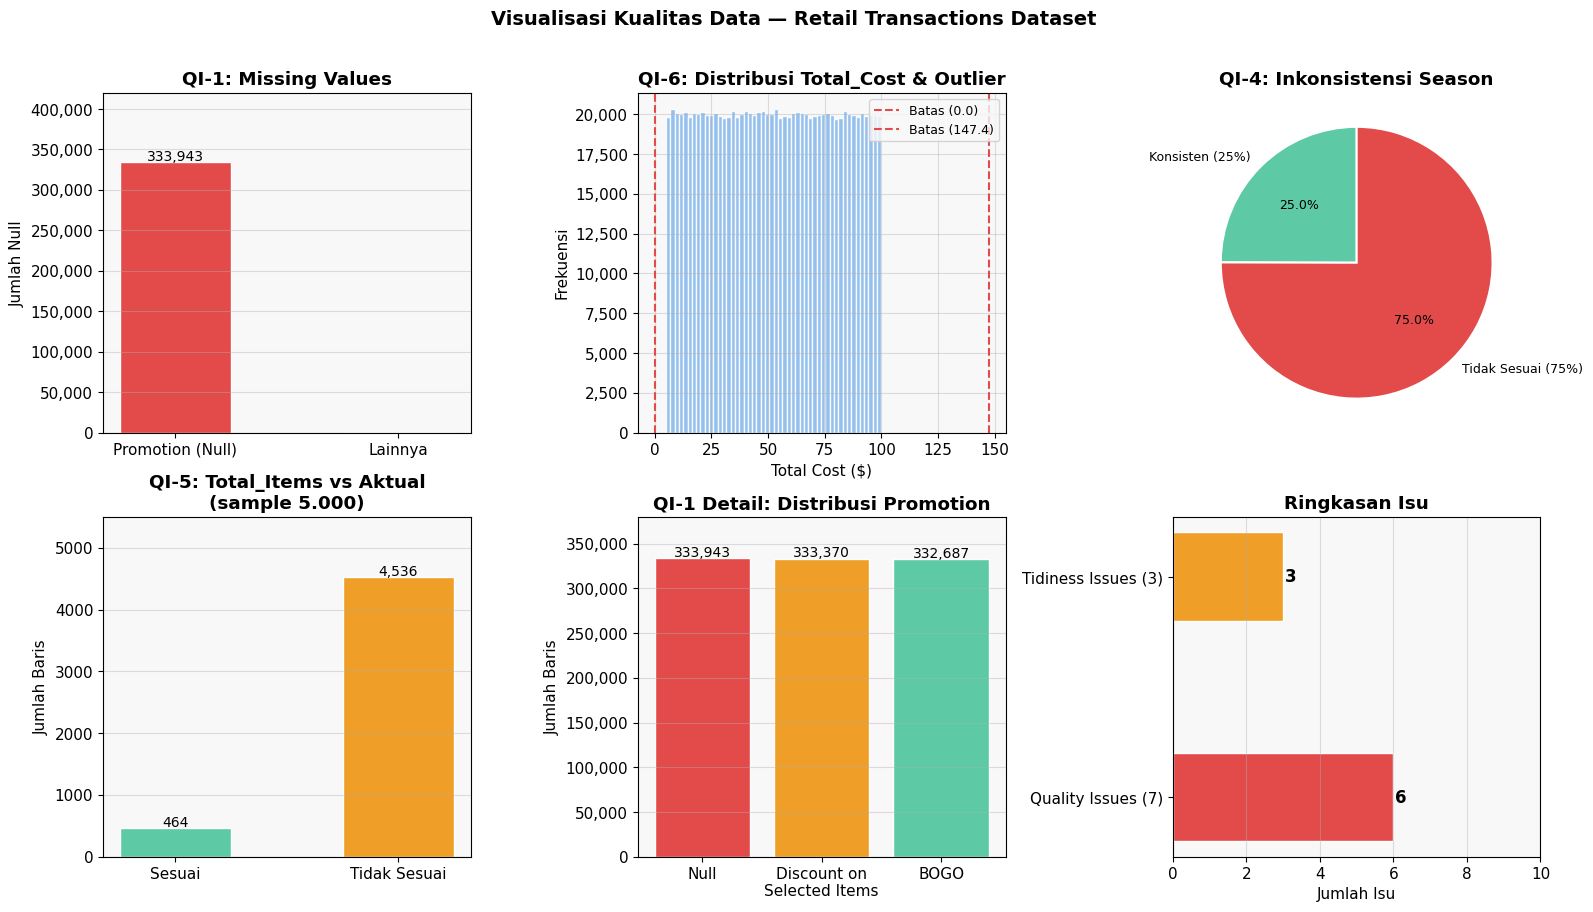

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Visualisasi Kualitas Data — Retail Transactions Dataset',
             fontsize=14, fontweight='bold', y=1.01)

# Plot 1: Missing Values
ax = axes[0,0]
ax.bar(['Promotion (Null)', 'Lainnya'], [missing['Promotion'], 0],
       color=['#E24B4A','#85B7EB'], edgecolor='white', width=0.5)
ax.set_title('QI-1: Missing Values', fontweight='bold')
ax.set_ylabel('Jumlah Null')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.text(0, missing['Promotion']+3000, f"{missing['Promotion']:,}",
        ha='center', fontsize=10)
ax.set_ylim(0, 420000)
ax.grid(axis='x', alpha=0)

# Plot 2: Distribusi Total_Cost
ax = axes[0,1]
ax.hist(df_clean['Total_Cost'], bins=50, color='#85B7EB', edgecolor='white', alpha=0.85)
ax.axvline(lower, color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Batas ({lower:.1f})')
ax.axvline(upper, color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Batas ({upper:.1f})')
ax.set_title('QI-6: Distribusi Total_Cost & Outlier', fontweight='bold')
ax.set_xlabel('Total Cost ($)')
ax.set_ylabel('Frekuensi')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=9)

# Plot 3: Season Mismatch
ax = axes[0,2]
ax.pie([len(df_clean)-len(season_mismatch), len(season_mismatch)],
       labels=['Konsisten (25%)', 'Tidak Sesuai (75%)'],
       colors=['#5DCAA5','#E24B4A'], autopct='%1.1f%%', startangle=90,
       textprops={'fontsize':9},
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('QI-4: Inkonsistensi Season', fontweight='bold')

# Plot 4: Total_Items Mismatch
ax = axes[1,0]
counts = pd.Series({'Sesuai': len(df_sample)-len(items_mismatch),
                    'Tidak Sesuai': len(items_mismatch)})
bars = ax.bar(counts.index, counts.values,
              color=['#5DCAA5','#EF9F27'], edgecolor='white', width=0.5)
ax.set_title('QI-5: Total_Items vs Aktual\n(sample 5.000)', fontweight='bold')
ax.set_ylabel('Jumlah Baris')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+20,
            f'{h:,}', ha='center', fontsize=10)
ax.set_ylim(0, 5500)
ax.grid(axis='x', alpha=0)

# Plot 5: Distribusi Promotion
ax = axes[1,1]
promo = df_clean['Promotion'].value_counts(dropna=False)
ax.bar(['Null','Discount on\nSelected Items','BOGO'], promo.values,
       color=['#E24B4A','#EF9F27','#5DCAA5'], edgecolor='white')
ax.set_title('QI-1 Detail: Distribusi Promotion', fontweight='bold')
ax.set_ylabel('Jumlah Baris')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for i, v in enumerate(promo.values):
    ax.text(i, v+2000, f'{v:,}', ha='center', fontsize=10)
ax.set_ylim(0, 380000)
ax.grid(axis='x', alpha=0)

# Plot 6: Ringkasan Isu
ax = axes[1,2]
ax.barh(['Quality Issues (7)','Tidiness Issues (3)'],
        [len(issues), len(tidiness_issues)],
        color=['#E24B4A','#EF9F27'], edgecolor='white', height=0.4)
ax.set_title('Ringkasan Isu', fontweight='bold')
ax.set_xlabel('Jumlah Isu')
for i, v in enumerate([len(issues), len(tidiness_issues)]):
    ax.text(v+0.05, i, str(v), va='center', fontsize=12, fontweight='bold')
ax.set_xlim(0, 10)
ax.grid(axis='y', alpha=0)

plt.tight_layout()
plt.savefig('assessing_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

Date diubah menjadi datetime

In [ ]:
print("── Konversi Kolom Date ke Datetime ──")

df_clean['Date'] = pd.to_datetime(df_clean['Date'])

print("✅ Kolom Date berhasil diubah ke datetime")

print(df_clean['Date'].dtype)

display(df_clean[['Date']].head())

── Konversi Kolom Date ke Datetime ──
✅ Kolom Date berhasil diubah ke datetime
datetime64[ns]


,Date
0,2022-01-21 06:27:29
1,2023-03-01 13:01:21
2,2024-03-21 15:37:04
3,2020-10-31 09:59:47
4,2020-12-10 00:59:59


# Cleaning: Explode Product

In [ ]:
print("── Fix QI-7 + TI-1: Pecah Kolom Product ──")

def parse_product_list(product_str):
    try:
        result = ast.literal_eval(product_str)
        if isinstance(result, list):
            return [str(item).strip() for item in result]
        return [str(result).strip()]
    except:
        items = re.findall(r"'([^']+)'", str(product_str))
        return items if items else [str(product_str).strip()]

df_clean['Product'] = df_clean['Product'].apply(parse_product_list)
df_clean = df_clean.explode('Product').reset_index(drop=True)
df_clean = df_clean.rename(columns={'Product': 'Product_Name'})

print(f"  etiap produk jadi 1 baris tersendiri.")
print(f"  Shape setelah explode: {df_clean.shape}")
display(df_clean[['Transaction_ID','Customer_Name','Product_Name','Total_Cost']].head(10))

── Fix QI-7 + TI-1: Pecah Kolom Product ──
  etiap produk jadi 1 baris tersendiri.
  Shape setelah explode: (3000343, 13)


,Transaction_ID,Customer_Name,Product_Name,Total_Cost
0,1000000000,Stacey Price,Ketchup,71.65
1,1000000000,Stacey Price,Shaving Cream,71.65
2,1000000000,Stacey Price,Light Bulbs,71.65
3,1000000001,Michelle Carlson,Ice Cream,25.93
4,1000000001,Michelle Carlson,Milk,25.93
5,1000000001,Michelle Carlson,Olive Oil,25.93
6,1000000001,Michelle Carlson,Bread,25.93
7,1000000001,Michelle Carlson,Potatoes,25.93
8,1000000002,Lisa Graves,Spinach,41.49
9,1000000003,Mrs. Patricia May,Tissues,39.34


In [ ]:
import pandas as pd
import numpy as np

df_real = df_clean.copy()
df_real['Date'] = pd.to_datetime(df_real['Date'])

# ============================================================
# PRICE DICTIONARY (IDR)
# ============================================================
price_dict = {
    # Buah & Sayur
    'Apple': 8000, 'Banana': 5000, 'Orange': 7000, 'Tomatoes': 6000,
    'Onions': 5000, 'Potatoes': 8000, 'Carrots': 6000, 'Spinach': 5000,
    # Daging & Protein
    'Beef': 85000, 'Chicken': 35000, 'Salmon': 120000, 'Shrimp': 65000,
    'Eggs': 28000, 'Tuna': 20000,
    # Susu & Dairy
    'Milk': 18000, 'Butter': 25000, 'Cheese': 35000, 'Yogurt': 15000, 'Ice Cream': 22000,
    # Karbohidrat
    'Rice': 15000, 'Bread': 18000, 'Pasta': 12000,
    # Bumbu & Saus
    'Ketchup': 14000, 'Mustard': 13000, 'Mayonnaise': 20000, 'BBQ Sauce': 18000,
    'Vinegar': 10000, 'Olive Oil': 45000, 'Pickles': 16000, 'Jam': 18000,
    'Honey': 35000, 'Syrup': 22000, 'Peanut Butter': 25000,
    # Minuman & Snack
    'Water': 5000, 'Soda': 12000, 'Coffee': 45000, 'Tea': 20000,
    'Chips': 15000, 'Cereal': 35000, 'Cereal Bars': 20000, 'Pancake Mix': 22000,
    'Canned Soup': 15000,
    # Kebersihan Diri
    'Soap': 8000, 'Shampoo': 22000, 'Shower Gel': 25000, 'Toothpaste': 15000,
    'Toothbrush': 12000, 'Deodorant': 25000, 'Shaving Cream': 20000,
    'Hair Gel': 18000, 'Hand Sanitizer': 15000, 'Razors': 30000,
    'Feminine Hygiene Products': 25000,
    # Kebersihan Rumah
    'Dish Soap': 12000, 'Laundry Detergent': 28000, 'Cleaning Spray': 18000,
    'Cleaning Rags': 10000, 'Sponges': 8000, 'Trash Bags': 15000,
    'Tissues': 12000, 'Toilet Paper': 18000, 'Paper Towels': 15000,
    # Peralatan Rumah
    'Broom': 35000, 'Mop': 45000, 'Dustpan': 20000, 'Dishware': 55000,
    'Trash Cans': 65000, 'Ironing Board': 150000, 'Iron': 250000,
    'Vacuum Cleaner': 750000, 'Lawn Mower': 1500000,
    # Bayi
    'Baby Wipes': 25000, 'Diapers': 55000,
    # Elektronik & Lainnya
    'Light Bulbs': 15000, 'Extension Cords': 35000, 'Power Strips': 55000,
    'Bath Towels': 55000, 'Air Freshener': 18000, 'Insect Repellent': 22000,
    'Plant Fertilizer': 30000, 'Garden Hose': 85000,
}

df_real['Estimated_Product_Price_IDR'] = df_real['Product_Name'].map(price_dict)

# Terjemahan Payment_Method
payment_map = {
    'Cash': 'Tunai', 'Credit Card': 'Kartu Kredit',
    'Debit Card': 'Kartu Debit', 'Mobile Payment': 'Pembayaran Digital',
}
df_real['Payment_Method'] = df_real['Payment_Method'].map(payment_map)

# Terjemahan Customer_Category
kategori_map = {
    'Homemaker': 'Ibu Rumah Tangga', 'Professional': 'Profesional',
    'Young Adult': 'Dewasa Muda', 'Retiree': 'Pensiunan',
    'Student': 'Pelajar/Mahasiswa', 'Middle-Aged': 'Paruh Baya',
    'Senior Citizen': 'Lansia', 'Teenager': 'Remaja',
}
df_real['Customer_Category'] = df_real['Customer_Category'].map(kategori_map)

# Terjemahan Discount_Applied
df_real['Discount_Applied'] = df_real['Discount_Applied'].map({True: 'Ya', False: 'Tidak'})

# Terjemahan nama produk
produk_map = {
    'Air Freshener': 'Pengharum Ruangan', 'Apple': 'Apel', 'BBQ Sauce': 'Saus BBQ',
    'Baby Wipes': 'Tisu Bayi', 'Banana': 'Pisang', 'Bath Towels': 'Handuk Mandi',
    'Beef': 'Daging Sapi', 'Bread': 'Roti', 'Broom': 'Sapu', 'Butter': 'Mentega',
    'Canned Soup': 'Sup Kaleng', 'Carrots': 'Wortel', 'Cereal': 'Sereal',
    'Cereal Bars': 'Batang Sereal', 'Cheese': 'Keju', 'Chicken': 'Ayam',
    'Chips': 'Keripik', 'Cleaning Rags': 'Kain Lap', 'Cleaning Spray': 'Semprot Pembersih',
    'Coffee': 'Kopi', 'Deodorant': 'Deodoran', 'Diapers': 'Popok',
    'Dish Soap': 'Sabun Cuci Piring', 'Dishware': 'Peralatan Makan', 'Dustpan': 'Pengki',
    'Eggs': 'Telur', 'Extension Cords': 'Kabel Ekstensi',
    'Feminine Hygiene Products': 'Produk Kebersihan Wanita',
    'Garden Hose': 'Selang Taman', 'Hair Gel': 'Gel Rambut',
    'Hand Sanitizer': 'Hand Sanitizer', 'Honey': 'Madu', 'Ice Cream': 'Es Krim',
    'Insect Repellent': 'Obat Nyamuk', 'Iron': 'Setrika', 'Ironing Board': 'Papan Setrika',
    'Jam': 'Selai', 'Ketchup': 'Saus Tomat', 'Laundry Detergent': 'Deterjen',
    'Lawn Mower': 'Mesin Pemotong Rumput', 'Light Bulbs': 'Lampu',
    'Mayonnaise': 'Mayones', 'Milk': 'Susu', 'Mop': 'Pel', 'Mustard': 'Saus Mustard',
    'Olive Oil': 'Minyak Zaitun', 'Onions': 'Bawang Bombay', 'Orange': 'Jeruk',
    'Pancake Mix': 'Tepung Pancake', 'Paper Towels': 'Tisu Dapur', 'Pasta': 'Pasta',
    'Peanut Butter': 'Selai Kacang', 'Pickles': 'Acar', 'Plant Fertilizer': 'Pupuk',
    'Potatoes': 'Kentang', 'Power Strips': 'Stop Kontak', 'Razors': 'Pisau Cukur',
    'Rice': 'Beras', 'Salmon': 'Salmon', 'Shampoo': 'Sampo',
    'Shaving Cream': 'Krim Cukur', 'Shower Gel': 'Sabun Mandi', 'Shrimp': 'Udang',
    'Soap': 'Sabun', 'Soda': 'Minuman Bersoda', 'Spinach': 'Bayam', 'Sponges': 'Spons',
    'Syrup': 'Sirup', 'Tea': 'Teh', 'Tissues': 'Tisu', 'Toilet Paper': 'Tisu Toilet',
    'Tomatoes': 'Tomat', 'Toothbrush': 'Sikat Gigi', 'Toothpaste': 'Pasta Gigi',
    'Trash Bags': 'Kantong Sampah', 'Trash Cans': 'Tempat Sampah', 'Tuna': 'Tuna',
    'Vacuum Cleaner': 'Penyedot Debu', 'Vinegar': 'Cuka', 'Water': 'Air Minum',
    'Yogurt': 'Yogurt',
}

df_real['Product'] = df_real['Product_Name'].map(produk_map)

# Rename Date → Datetime
df_real = df_real.rename(columns={'Date': 'Datetime'})

final_output = df_real[[
    'Datetime', 'Customer_Name', 'Product',
    'Estimated_Product_Price_IDR', 'Payment_Method',
    'Discount_Applied', 'Customer_Category', 'Promotion'
]]

print(f" Shape: {final_output.shape}")
print(f"\nCek harga per produk (sudah logis):")
print(final_output.groupby('Product')['Estimated_Product_Price_IDR'].mean().sort_values(ascending=False).head(10))
display(final_output.head(20))

 Shape: (3000343, 8)

Cek harga per produk (sudah logis):
Product
Mesin Pemotong Rumput   1500000.00
Penyedot Debu            750000.00
Setrika                  250000.00
Papan Setrika            150000.00
Salmon                   120000.00
Selang Taman              85000.00
Daging Sapi               85000.00
Udang                     65000.00
Tempat Sampah             65000.00
Handuk Mandi              55000.00
Name: Estimated_Product_Price_IDR, dtype: float64


,Datetime,Customer_Name,Product,Estimated_Product_Price_IDR,Payment_Method,Discount_Applied,Customer_Category,Promotion
0,2022-01-21 06:27:29,Stacey Price,Saus Tomat,14000,Pembayaran Digital,Ya,Ibu Rumah Tangga,NaN
1,2022-01-21 06:27:29,Stacey Price,Krim Cukur,20000,Pembayaran Digital,Ya,Ibu Rumah Tangga,NaN
2,2022-01-21 06:27:29,Stacey Price,Lampu,15000,Pembayaran Digital,Ya,Ibu Rumah Tangga,NaN
3,2023-03-01 13:01:21,Michelle Carlson,Es Krim,22000,Tunai,Ya,Profesional,BOGO (Buy One Get One)
4,2023-03-01 13:01:21,Michelle Carlson,Susu,18000,Tunai,Ya,Profesional,BOGO (Buy One Get One)
5,2023-03-01 13:01:21,Michelle Carlson,Minyak Zaitun,45000,Tunai,Ya,Profesional,BOGO (Buy One Get One)
6,2023-03-01 13:01:21,Michelle Carlson,Roti,18000,Tunai,Ya,Profesional,BOGO (Buy One Get One)
7,2023-03-01 13:01:21,Michelle Carlson,Kentang,8000,Tunai,Ya,Profesional,BOGO (Buy One Get One)
8,2024-03-21 15:37:04,Lisa Graves,Bayam,5000,Kartu Kredit,Ya,Profesional,NaN
9,2020-10-31 09:59:47,Mrs. Patricia May,Tisu,12000,Pembayaran Digital,Ya,Ibu Rumah Tangga,NaN


In [ ]:
# Simpan hasil cleaning ke file CSV
final_output.to_csv('retail_cleaned.csv', index=False)

print(" File berhasil disimpan: retail_cleaned.csv")

 File berhasil disimpan: retail_cleaned.csv


# Exploratory Data Analysis (EDA)

Menjawab 5 pertanyaan bisnis menggunakan dataset final_output.

1. Produk & Revenue "Produk apa yang paling sering terjual dan menghasilkan total nilai penjualan tertinggi?"

2. Tren Waktu "Bagaimana tren jumlah transaksi dan total estimasi nilai belanja (Estimated_Product_Price_IDR) per bulan dari waktu ke waktu?"

3. Pola Penjualan per Quarter "Pada quarter mana penjualan produk paling tinggi dan apakah polanya konsisten setiap tahun?"

4. Perilaku Pelanggan "Kategori pelanggan mana yang paling banyak bertransaksi dan memiliki rata-rata nilai belanja tertinggi?"

5. Analisis Risiko & Rekomendasi Restock "Produk mana yang berisiko kehabisan stok dan berapa jumlah restock yang direkomendasikan berdasarkan tren penjualan historis?"

In [ ]:
df_eda = final_output.copy()

# Fix NaN di kolom Promotion
df_eda['Promotion'] = df_eda['Promotion'].fillna('No Promotion')

# Ekstrak komponen waktu dari Datetime
df_eda['Datetime'] = pd.to_datetime(df_eda['Datetime'])
df_eda['YearMonth'] = df_eda['Datetime'].dt.to_period('M')

print(f" df_eda siap. Shape: {df_eda.shape}")
print(f"Kolom: {df_eda.columns.tolist()}")
display(df_eda.head())

 df_eda siap. Shape: (3000343, 9)
Kolom: ['Datetime', 'Customer_Name', 'Product', 'Estimated_Product_Price_IDR', 'Payment_Method', 'Discount_Applied', 'Customer_Category', 'Promotion', 'YearMonth']


,Datetime,Customer_Name,Product,Estimated_Product_Price_IDR,Payment_Method,Discount_Applied,Customer_Category,Promotion,YearMonth
0,2022-01-21 06:27:29,Stacey Price,Saus Tomat,14000,Pembayaran Digital,Ya,Ibu Rumah Tangga,No Promotion,2022-01
1,2022-01-21 06:27:29,Stacey Price,Krim Cukur,20000,Pembayaran Digital,Ya,Ibu Rumah Tangga,No Promotion,2022-01
2,2022-01-21 06:27:29,Stacey Price,Lampu,15000,Pembayaran Digital,Ya,Ibu Rumah Tangga,No Promotion,2022-01
3,2023-03-01 13:01:21,Michelle Carlson,Es Krim,22000,Tunai,Ya,Profesional,BOGO (Buy One Get One),2023-03
4,2023-03-01 13:01:21,Michelle Carlson,Susu,18000,Tunai,Ya,Profesional,BOGO (Buy One Get One),2023-03


Pertanyaan 1: Produk & Harga

PERTANYAAN 1: Produk Terlaris & Nilai Penjualan Tertinggi


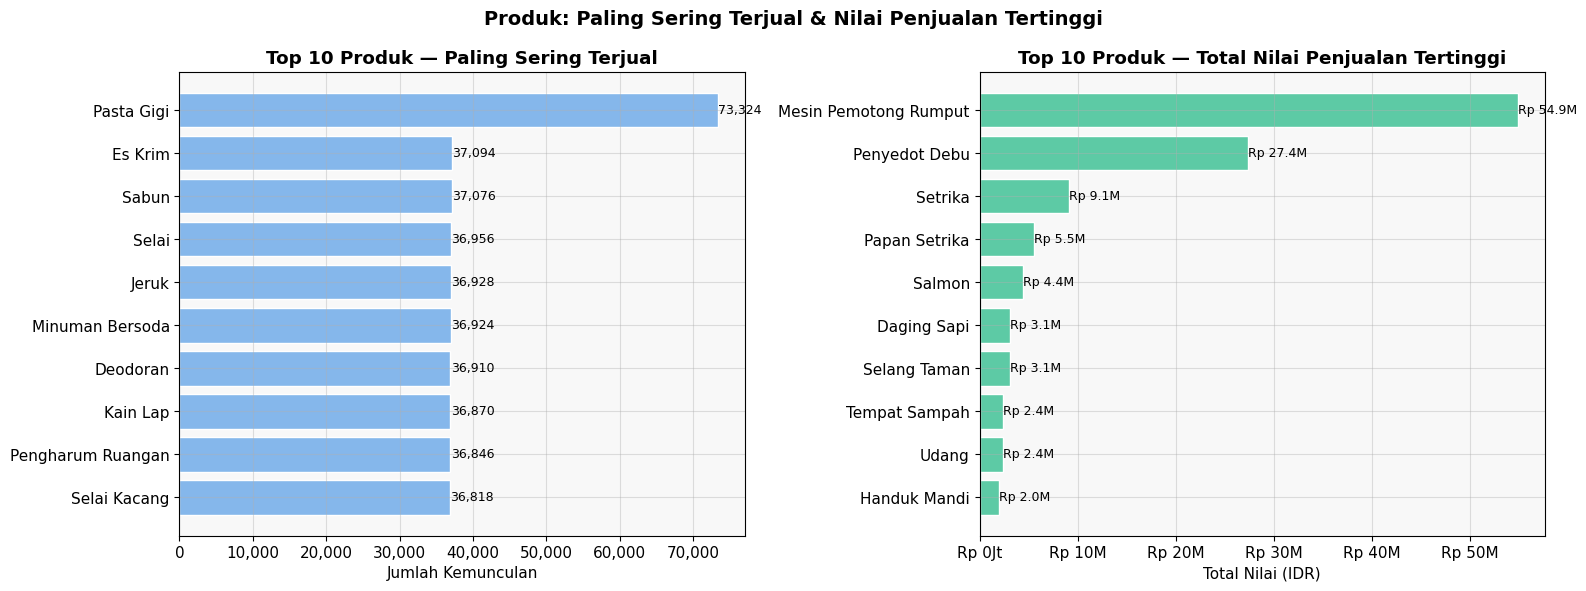


 Insight:
  Produk paling sering terjual    : Pasta Gigi (73,324 kali)
  Produk nilai penjualan tertinggi: Mesin Pemotong Rumput (Rp 54,864,000,000)


In [ ]:
print("PERTANYAAN 1: Produk Terlaris & Nilai Penjualan Tertinggi")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Produk: Paling Sering Terjual & Nilai Penjualan Tertinggi',
             fontsize=14, fontweight='bold')

# Kiri: Top 10 produk paling sering terjual
top_freq = (df_eda['Product']
            .value_counts()
            .head(10)
            .reset_index())
top_freq.columns = ['Product', 'Jumlah']

axes[0].barh(top_freq['Product'][::-1],
             top_freq['Jumlah'][::-1],
             color='#85B7EB', edgecolor='white')
axes[0].set_title('Top 10 Produk — Paling Sering Terjual', fontweight='bold')
axes[0].set_xlabel('Jumlah Kemunculan')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(top_freq['Jumlah'][::-1]):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Kanan: Top 10 produk dengan total nilai penjualan tertinggi
top_nilai = (df_eda.groupby('Product')
             .apply(lambda x: (x['Estimated_Product_Price_IDR']).sum())
             .sort_values(ascending=False)
             .head(10)
             .reset_index())
top_nilai.columns = ['Product', 'Total_Nilai']

axes[1].barh(top_nilai['Product'][::-1],
             top_nilai['Total_Nilai'][::-1],
             color='#5DCAA5', edgecolor='white')
axes[1].set_title('Top 10 Produk — Total Nilai Penjualan Tertinggi', fontweight='bold')
axes[1].set_xlabel('Total Nilai (IDR)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp {int(x/1e9):.0f}M' if x >= 1e9 else f'Rp {int(x/1e6):.0f}Jt'))
for i, v in enumerate(top_nilai['Total_Nilai'][::-1]):
    label = f'Rp {v/1e9:.1f}M' if v >= 1e9 else f'Rp {v/1e6:.0f}Jt'
    axes[1].text(v + 1e6, i, label, va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_pertanyaan1.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Insight:")
print(f"  Produk paling sering terjual    : {top_freq.iloc[0]['Product']} "
      f"({top_freq.iloc[0]['Jumlah']:,} kali)")
print(f"  Produk nilai penjualan tertinggi: {top_nilai.iloc[0]['Product']} "
      f"(Rp {int(top_nilai.iloc[0]['Total_Nilai']):,})")

Pertanyaan 2: Tren Waktu

PERTANYAAN 2: Tren Waktu


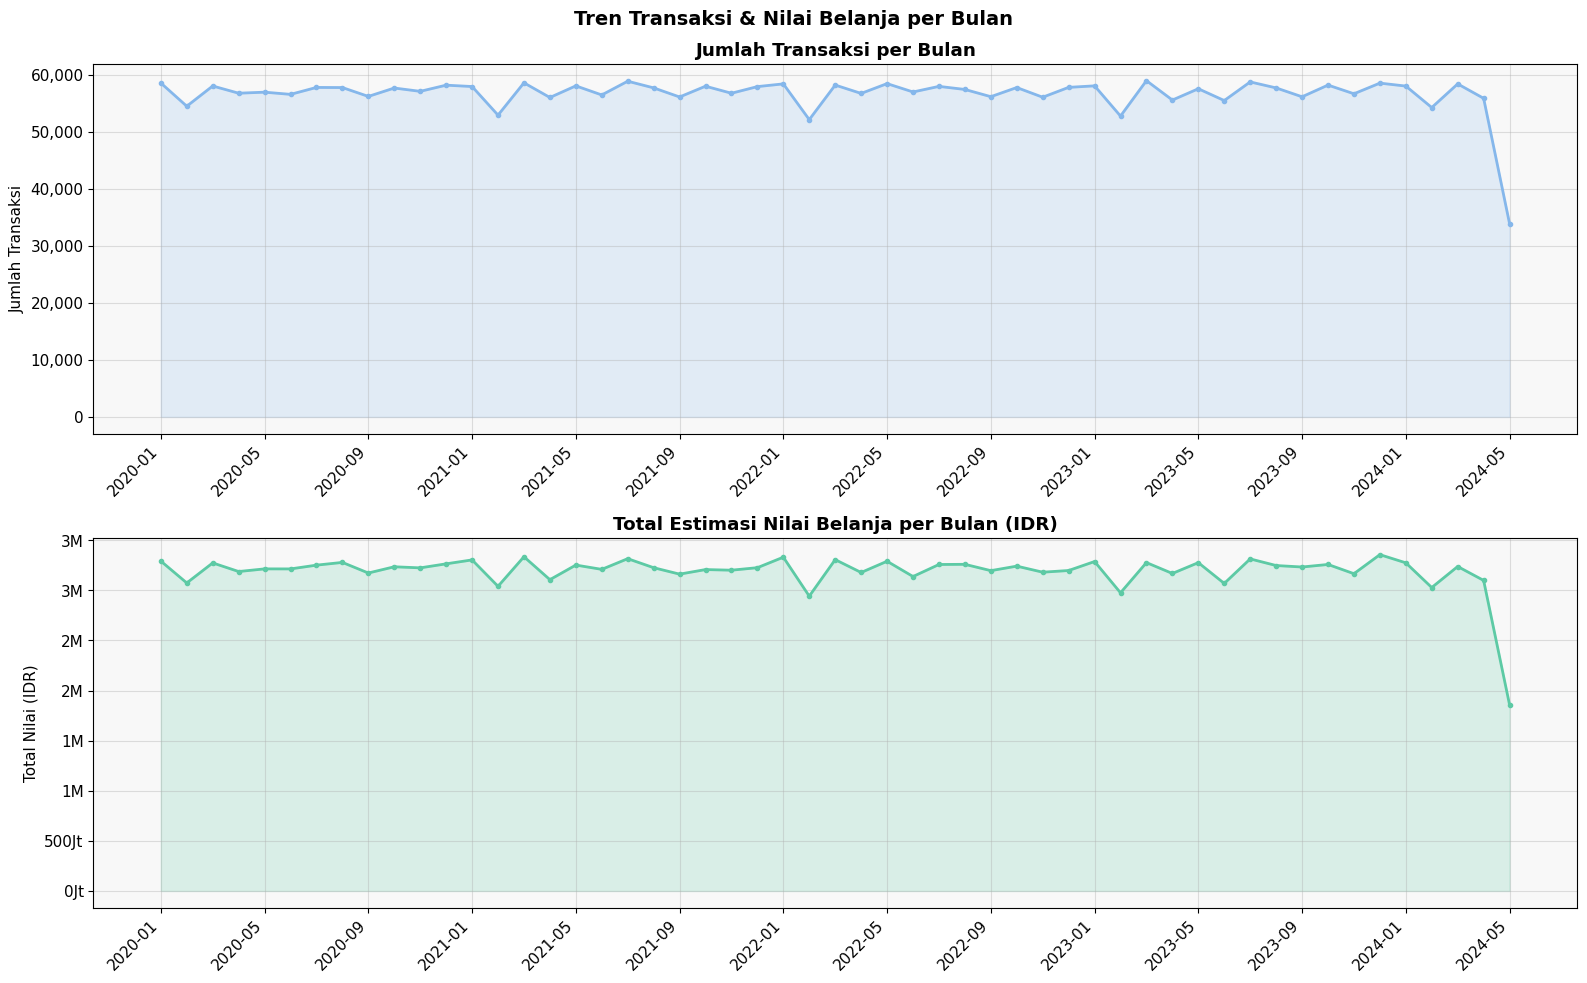


 Insight:
  Bulan transaksi tertinggi: 2023-03 (58,971 transaksi)
  Nilai belanja tertinggi  : Rp 3,355,971,000


In [ ]:
print("PERTANYAAN 2: Tren Waktu")
print("=" * 60)

tren = (df_eda.groupby('YearMonth')
        .agg(
            Jumlah_Transaksi=('Product', 'count'),
            Total_Nilai=('Estimated_Product_Price_IDR', 'sum')
        )
        .reset_index())
tren['YearMonth_str'] = tren['YearMonth'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Tren Transaksi & Nilai Belanja per Bulan',
             fontsize=14, fontweight='bold')

# Jumlah transaksi
axes[0].plot(tren['YearMonth_str'], tren['Jumlah_Transaksi'],
             color='#85B7EB', linewidth=2, marker='o', markersize=3)
axes[0].fill_between(tren['YearMonth_str'], tren['Jumlah_Transaksi'],
                     alpha=0.2, color='#85B7EB')
axes[0].set_title('Jumlah Transaksi per Bulan', fontweight='bold')
axes[0].set_ylabel('Jumlah Transaksi')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
tick_step = max(1, len(tren) // 12)
axes[0].set_xticks(range(0, len(tren), tick_step))
axes[0].set_xticklabels(tren['YearMonth_str'][::tick_step], rotation=45, ha='right')

# Bawah: Total nilai belanja
axes[1].plot(tren['YearMonth_str'], tren['Total_Nilai'],
             color='#5DCAA5', linewidth=2, marker='o', markersize=3)
axes[1].fill_between(tren['YearMonth_str'], tren['Total_Nilai'],
                     alpha=0.2, color='#5DCAA5')
axes[1].set_title('Total Estimasi Nilai Belanja per Bulan (IDR)', fontweight='bold')
axes[1].set_ylabel('Total Nilai (IDR)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1e9):,}M' if x >= 1e9 else f'{int(x/1e6):,}Jt'))
axes[1].set_xticks(range(0, len(tren), tick_step))
axes[1].set_xticklabels(tren['YearMonth_str'][::tick_step], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('eda_pertanyaan2.png', dpi=150, bbox_inches='tight')
plt.show()

bulan_tertinggi = tren.loc[tren['Jumlah_Transaksi'].idxmax()]
print("\n Insight:")
print(f"  Bulan transaksi tertinggi: {bulan_tertinggi['YearMonth_str']} "
      f"({int(bulan_tertinggi['Jumlah_Transaksi']):,} transaksi)")
print(f"  Nilai belanja tertinggi  : Rp {int(tren['Total_Nilai'].max()):,}")

Pertanyaan 3: Efektivitas Diskon & Promosi


PERTANYAAN 3: Pola Penjualan per Quarter


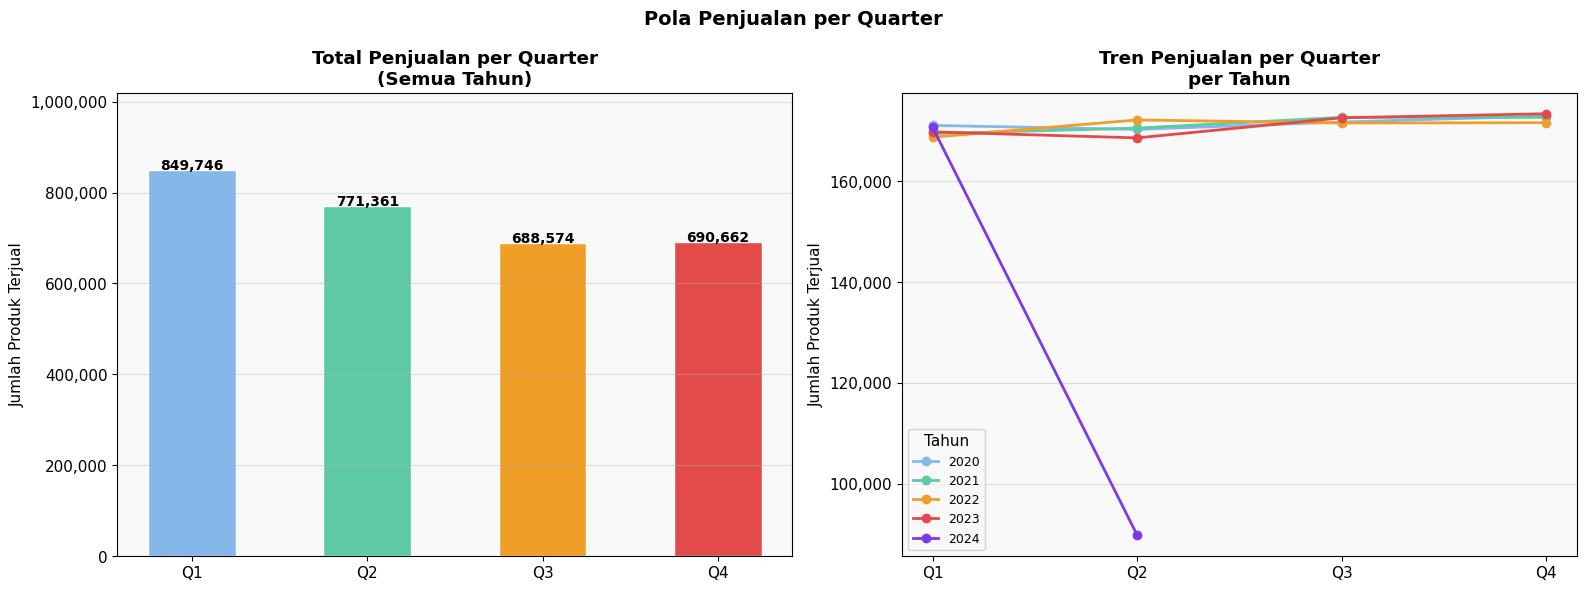


 Insight:
  Quarter penjualan tertinggi : Q1 (849,746 produk)
  Quarter penjualan terendah  : Q3 (688,574 produk)
  Selisih                     : 161,172 produk


In [ ]:
print("PERTANYAAN 3: Pola Penjualan per Quarter")
print("=" * 60)

# Ekstrak quarter dan year dari Datetime
df_eda['Year']    = pd.to_datetime(df_eda['Datetime']).dt.year
df_eda['Quarter'] = pd.to_datetime(df_eda['Datetime']).dt.quarter
df_eda['Quarter_Label'] = 'Q' + df_eda['Quarter'].astype(str)

# Agregasi per Quarter per Tahun
df_quarter = (df_eda.groupby(['Year', 'Quarter_Label'])['Product']
              .count()
              .reset_index(name='Qty_Terjual'))

# Agregasi total per Quarter (semua tahun)
df_quarter_total = (df_eda.groupby('Quarter_Label')['Product']
                    .count()
                    .reset_index(name='Qty_Terjual'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pola Penjualan per Quarter',
             fontsize=14, fontweight='bold')

# Kiri: Total qty per quarter (semua tahun digabung)
bars = axes[0].bar(df_quarter_total['Quarter_Label'],
                   df_quarter_total['Qty_Terjual'],
                   color=['#85B7EB', '#5DCAA5', '#EF9F27', '#E24B4A'],
                   edgecolor='white', width=0.5)
axes[0].set_title('Total Penjualan per Quarter\n(Semua Tahun)', fontweight='bold')
axes[0].set_ylabel('Jumlah Produk Terjual')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 1000,
                 f'{int(h):,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, df_quarter_total['Qty_Terjual'].max() * 1.2)
axes[0].grid(axis='x', alpha=0)

# Kanan: Tren per quarter per tahun (line chart)
colors = ['#85B7EB', '#5DCAA5', '#EF9F27', '#E24B4A', '#7C3AED']
for i, year in enumerate(sorted(df_quarter['Year'].unique())):
    data_year = df_quarter[df_quarter['Year'] == year]
    axes[1].plot(data_year['Quarter_Label'], data_year['Qty_Terjual'],
                 marker='o', linewidth=2, markersize=6,
                 label=str(year), color=colors[i % len(colors)])

axes[1].set_title('Tren Penjualan per Quarter\nper Tahun', fontweight='bold')
axes[1].set_ylabel('Jumlah Produk Terjual')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(title='Tahun', fontsize=9)
axes[1].grid(axis='x', alpha=0)

plt.tight_layout()
plt.savefig('eda_pertanyaan3.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
top_quarter = df_quarter_total.sort_values('Qty_Terjual', ascending=False).iloc[0]
bot_quarter = df_quarter_total.sort_values('Qty_Terjual', ascending=False).iloc[-1]

print("\n Insight:")
print(f"  Quarter penjualan tertinggi : {top_quarter['Quarter_Label']} "
      f"({int(top_quarter['Qty_Terjual']):,} produk)")
print(f"  Quarter penjualan terendah  : {bot_quarter['Quarter_Label']} "
      f"({int(bot_quarter['Qty_Terjual']):,} produk)")
print(f"  Selisih                     : "
      f"{int(top_quarter['Qty_Terjual'] - bot_quarter['Qty_Terjual']):,} produk")

Pertanyaan 4: Perilaku Pelanggan

PERTANYAAN 4: Perilaku Pelanggan


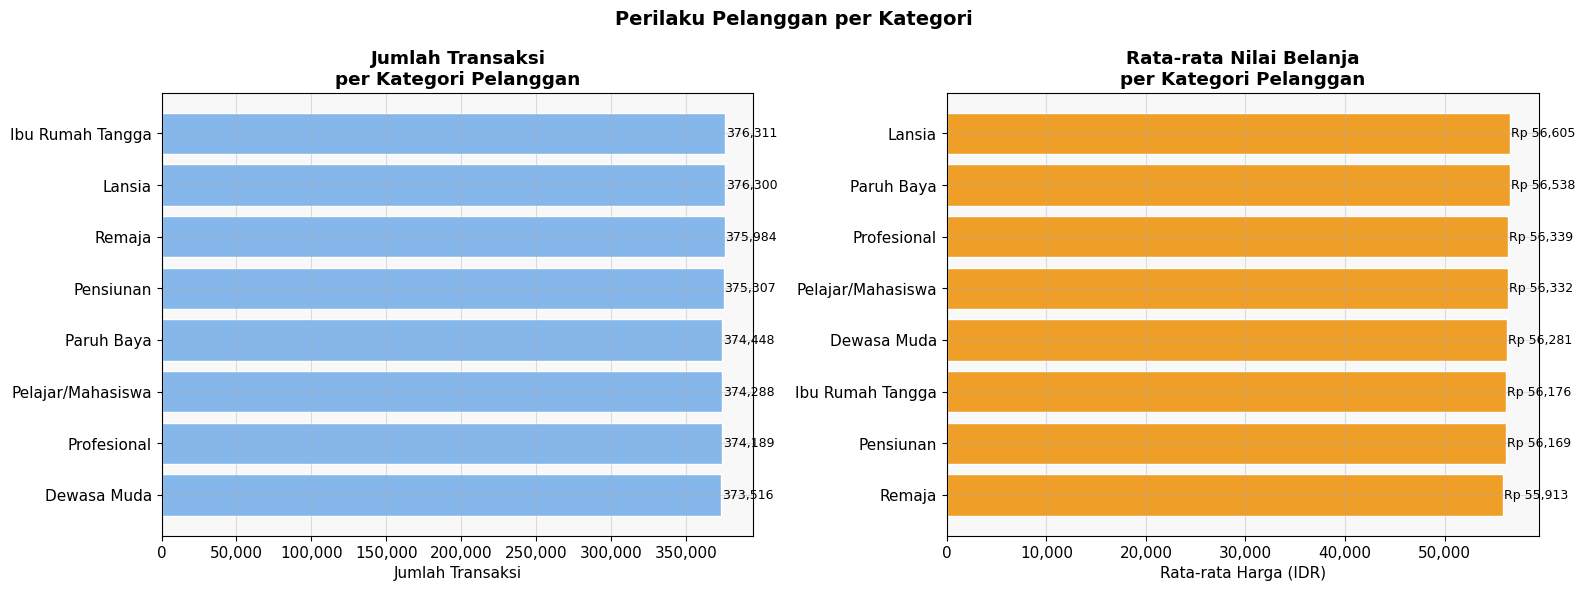


 Insight:
  Kategori transaksi terbanyak : Ibu Rumah Tangga (376,311 transaksi)
  Kategori nilai belanja tertinggi: Lansia (Rp 56,605)


In [ ]:
print("PERTANYAAN 4: Perilaku Pelanggan")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Perilaku Pelanggan per Kategori',
             fontsize=14, fontweight='bold')

# Jumlah transaksi per kategori
jumlah = (df_eda.groupby('Customer_Category')['Product']
          .count().sort_values(ascending=False).reset_index())
jumlah.columns = ['Customer_Category', 'Jumlah_Transaksi']

bars = axes[0].barh(jumlah['Customer_Category'][::-1],
                    jumlah['Jumlah_Transaksi'][::-1],
                    color='#85B7EB', edgecolor='white')
axes[0].set_title('Jumlah Transaksi\nper Kategori Pelanggan', fontweight='bold')
axes[0].set_xlabel('Jumlah Transaksi')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 500, bar.get_y() + bar.get_height()/2,
                 f'{int(w):,}', va='center', fontsize=9)

# Kanan: Rata-rata nilai belanja per kategori
rata = (df_eda.groupby('Customer_Category')['Estimated_Product_Price_IDR']
        .mean().sort_values(ascending=False).reset_index())
rata.columns = ['Customer_Category', 'Rata_Nilai']

bars2 = axes[1].barh(rata['Customer_Category'][::-1],
                     rata['Rata_Nilai'][::-1],
                     color='#EF9F27', edgecolor='white')
axes[1].set_title('Rata-rata Nilai Belanja\nper Kategori Pelanggan', fontweight='bold')
axes[1].set_xlabel('Rata-rata Harga (IDR)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w + 100, bar.get_y() + bar.get_height()/2,
                 f'Rp {int(w):,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_pertanyaan4.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Insight:")
print(f"  Kategori transaksi terbanyak : {jumlah.iloc[0]['Customer_Category']} "
      f"({jumlah.iloc[0]['Jumlah_Transaksi']:,} transaksi)")
print(f"  Kategori nilai belanja tertinggi: {rata.iloc[0]['Customer_Category']} "
      f"(Rp {int(rata.iloc[0]['Rata_Nilai']):,})")

Pertanyaan 5: Analisis Risiko & Rekomendasi Restock

PERTANYAAN 5: Analisis Risiko & Rekomendasi Restock


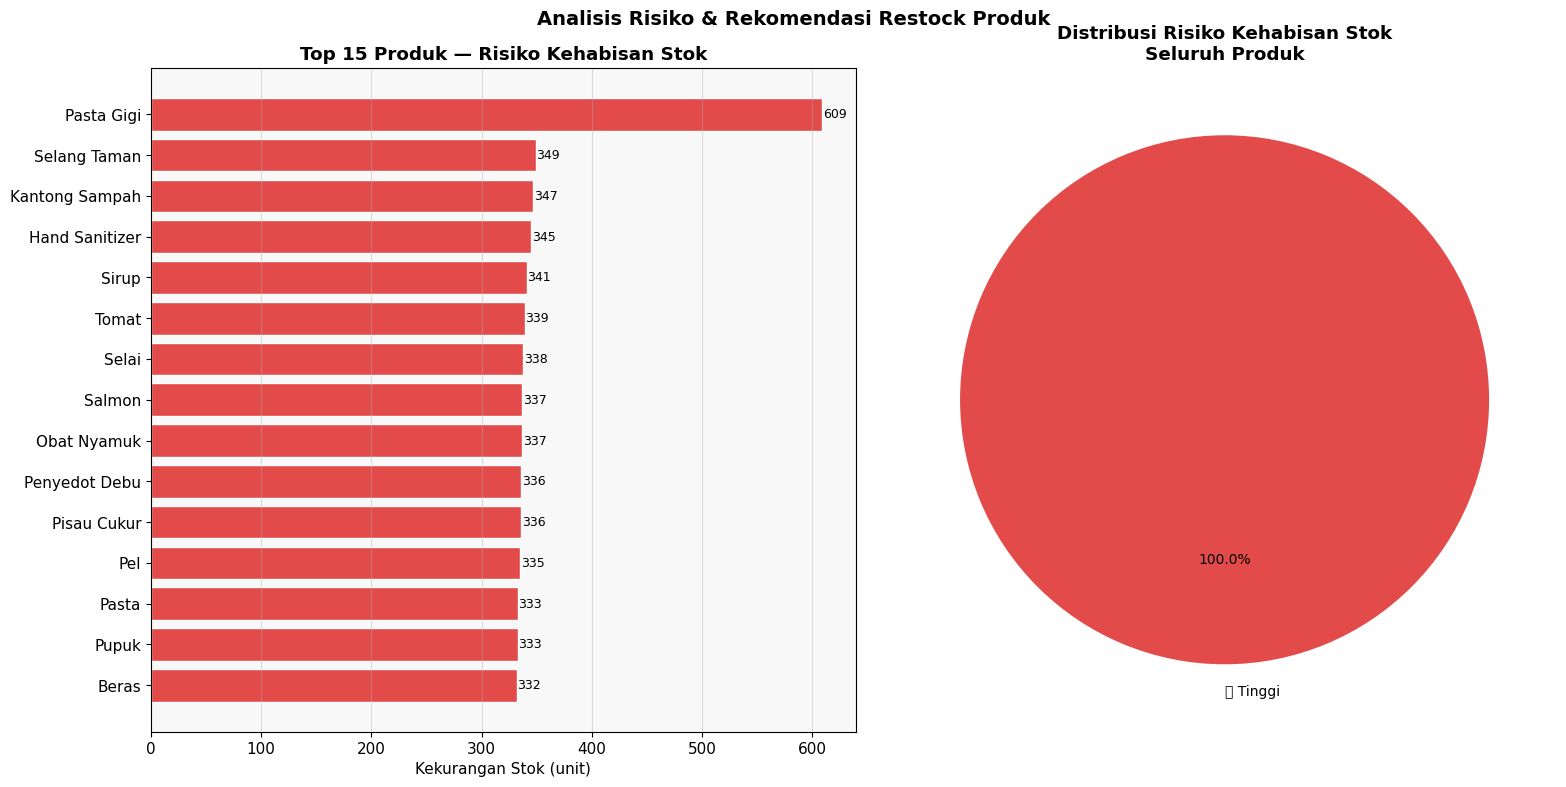


 Tabel Rekomendasi Restock:
----------------------------------------------------------------------
Produk                           Qty Bulan Ini     Rekomendasi     Risiko
----------------------------------------------------------------------
  Pasta Gigi                               817           1,426   🔴 Tinggi
  Selang Taman                             388             737   🔴 Tinggi
  Kantong Sampah                           398             745   🔴 Tinggi
  Hand Sanitizer                           381             726   🔴 Tinggi
  Sirup                                    381             722   🔴 Tinggi
  Tomat                                    401             740   🔴 Tinggi
  Selai                                    402             740   🔴 Tinggi
  Salmon                                   432             769   🔴 Tinggi
  Obat Nyamuk                              398             735   🔴 Tinggi
  Penyedot Debu                            386             722   🔴 Tinggi
  Pisau Cukur  

In [ ]:
print("PERTANYAAN 5: Analisis Risiko & Rekomendasi Restock")
print("=" * 60)

# Ambil data bulan terakhir sebagai acuan stok saat ini
bulan_terakhir = df_fe['YearMonth'].max()
df_terakhir = df_fe[df_fe['YearMonth'] == bulan_terakhir].copy()

# Hitung rata-rata penjualan 3 bulan terakhir per produk
df_fe_sorted = df_fe.sort_values(['Product', 'YearMonth'])
df_avg3 = (df_fe_sorted.groupby('Product')
           .apply(lambda x: x.tail(3)['Qty_Sold'].mean())
           .reset_index(name='Avg_3Bulan'))

# Gabungkan
df_restock = df_terakhir[['Product', 'Qty_Sold']].merge(df_avg3, on='Product')

# Hitung rekomendasi restock (1.2x rata-rata 3 bulan = buffer 20%)
df_restock['Rekomendasi_Restock'] = (df_restock['Avg_3Bulan'] * 1.2).round().astype(int)

# Hitung risiko: selisih antara rekomendasi dan qty bulan terakhir
df_restock['Selisih'] = df_restock['Rekomendasi_Restock'] - df_restock['Qty_Sold']

# Kategorikan risiko
def kategori_risiko(selisih):
    if selisih > 50:
        return '🔴 Tinggi'
    elif selisih > 20:
        return '🟡 Sedang'
    else:
        return '🟢 Aman'

df_restock['Risiko'] = df_restock['Selisih'].apply(kategori_risiko)
df_restock = df_restock.sort_values('Selisih', ascending=False).reset_index(drop=True)

# VISUALISASI
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Analisis Risiko & Rekomendasi Restock Produk',
             fontsize=14, fontweight='bold')

# Kiri: Top 15 produk risiko tertinggi
top15 = df_restock.head(15)
colors_risk = top15['Risiko'].map({
    '🔴 Tinggi': '#E24B4A',
    '🟡 Sedang': '#EF9F27',
    '🟢 Aman'  : '#5DCAA5'
})

axes[0].barh(top15['Product'][::-1],
             top15['Selisih'][::-1],
             color=colors_risk[::-1], edgecolor='white')
axes[0].set_title('Top 15 Produk — Risiko Kehabisan Stok', fontweight='bold')
axes[0].set_xlabel('Kekurangan Stok (unit)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(top15['Selisih'][::-1]):
    axes[0].text(v + 0.5, i, f'{int(v):,}', va='center', fontsize=9)
axes[0].grid(axis='y', alpha=0)

# Kanan: Distribusi kategori risiko (pie chart)
risiko_count = df_restock['Risiko'].value_counts()
axes[1].pie(risiko_count.values,
            labels=risiko_count.index,
            autopct='%1.1f%%',
            colors=['#E24B4A', '#EF9F27', '#5DCAA5'],
            startangle=90,
            textprops={'fontsize': 10},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Distribusi Risiko Kehabisan Stok\nSeluruh Produk', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_pertanyaan5.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabel rekomendasi restock
print("\n Tabel Rekomendasi Restock:")
print("-" * 70)
print(f"{'Produk':<30} {'Qty Bulan Ini':>15} {'Rekomendasi':>15} {'Risiko':>10}")
print("-" * 70)
for _, row in df_restock.head(20).iterrows():
    print(f"  {row['Product']:<28} {int(row['Qty_Sold']):>15,} "
          f"{int(row['Rekomendasi_Restock']):>15,} {row['Risiko']:>10}")
print("-" * 70)

print(f"\n Insight:")
print(f"  Total produk risiko tinggi : {(df_restock['Risiko']=='🔴 Tinggi').sum()} produk")
print(f"  Total produk risiko sedang : {(df_restock['Risiko']=='🟡 Sedang').sum()} produk")
print(f"  Total produk aman          : {(df_restock['Risiko']=='🟢 Aman').sum()} produk")
print(f"  Produk paling perlu restock: {df_restock.iloc[0]['Product']} "
      f"(kekurangan {int(df_restock.iloc[0]['Selisih']):,} unit)")

# Feature Engginering

In [ ]:
# AGREGASI DASAR per Produk per Bulan
df_fe = (df_eda.groupby(['YearMonth', 'Product'])
         .agg(
             Qty_Sold     = ('Product', 'count'),
             Total_Sales  = ('Estimated_Product_Price_IDR', 'sum'),
             Avg_Sales    = ('Estimated_Product_Price_IDR', 'mean'),
             Discount_Rate= ('Discount_Applied', lambda x: (x == 'Ya').mean()),
         )
         .reset_index())

df_fe['YearMonth'] = df_fe['YearMonth'].dt.to_timestamp()
df_fe = df_fe.sort_values(['Product', 'YearMonth']).reset_index(drop=True)

print(f" Agregasi dasar selesai. Shape: {df_fe.shape}")

 Agregasi dasar selesai. Shape: (4293, 6)


In [ ]:
# FITUR WAKTU
df_fe['Year']    = df_fe['YearMonth'].dt.year
df_fe['Month']   = df_fe['YearMonth'].dt.month
df_fe['Quarter'] = df_fe['YearMonth'].dt.quarter

print(" Fitur waktu selesai: Year, Month, Quarter")

 Fitur waktu selesai: Year, Month, Quarter


In [ ]:
# LAG FEATURES (penjualan bulan sebelumnya)
df_fe['Lag_1'] = df_fe.groupby('Product')['Qty_Sold'].shift(1)
df_fe['Lag_2'] = df_fe.groupby('Product')['Qty_Sold'].shift(2)
df_fe['Lag_3'] = df_fe.groupby('Product')['Qty_Sold'].shift(3)

print(" Lag features selesai: Lag_1, Lag_2, Lag_3")

 Lag features selesai: Lag_1, Lag_2, Lag_3


In [ ]:
# ROLLING MEAN (tren jangka pendek)
df_fe['Rolling_Mean_3'] = (df_fe.groupby('Product')['Qty_Sold']
                           .transform(lambda x: x.shift(1).rolling(3).mean()))

df_fe['Rolling_Mean_6'] = (df_fe.groupby('Product')['Qty_Sold']
                           .transform(lambda x: x.shift(1).rolling(6).mean()))

print(" Rolling Mean selesai: Rolling_Mean_3, Rolling_Mean_6")

 Rolling Mean selesai: Rolling_Mean_3, Rolling_Mean_6


In [ ]:
# DUMMY INVENTORY (stok simulasi)
# Helper: normalisasi min-max ke rentang UMKM (out_min–out_max)
rm3_min = df_fe['Rolling_Mean_3'].min()
rm3_max = df_fe['Rolling_Mean_3'].max()

def scale_to_umkm(series, out_min=5, out_max=100):
    """Min-max scaling ke rentang UMKM agar proporsi antar produk tetap terjaga."""
    return out_min + (series - rm3_min) / (rm3_max - rm3_min) * (out_max - out_min)

# Versi scaled dari rolling mean (skala UMKM)
df_fe['RM3_Scaled'] = scale_to_umkm(df_fe['Rolling_Mean_3'])

# Safety Stock = 15% dari rata-rata 3 bulan (skala UMKM), min 1, max 15
df_fe['Safety_Stock']  = (df_fe['RM3_Scaled'] * 0.15).round().clip(lower=1, upper=15)

# Reorder Point = 50% rolling mean + safety stock, max 60
df_fe['Reorder_Point'] = (df_fe['RM3_Scaled'] * 0.5 + df_fe['Safety_Stock']).round().clip(lower=3, upper=60)

# Stok Awal bulan = 1.2x rolling mean (skala UMKM), max 100 unit
df_fe['Stok_Awal']     = (df_fe['RM3_Scaled'] * 1.2).round().clip(lower=5, upper=100)

# Stok Akhir = stok awal - qty terjual (di-scale ke UMKM), min 0
df_fe['Stok_Akhir']    = (df_fe['Stok_Awal'] - scale_to_umkm(df_fe['Qty_Sold'])).round().clip(lower=0)

# Status stok
def status_stok(row):
    if pd.isna(row['Reorder_Point']):
        return 'Data Tidak Cukup'
    elif row['Stok_Akhir'] <= 0:
        return '🔴 Habis'
    elif row['Stok_Akhir'] <= row['Reorder_Point']:
        return '🟡 Perlu Restock'
    else:
        return '🟢 Aman'

df_fe['Status_Stok'] = df_fe.apply(status_stok, axis=1)

# Hapus kolom helper
df_fe = df_fe.drop(columns=['RM3_Scaled'])

print(" Dummy inventory (skala UMKM) selesai!")
print(f"\nRentang Stok Awal  : {int(df_fe['Stok_Awal'].min())} – {int(df_fe['Stok_Awal'].max())} unit")
print(f"Rentang Safety Stock: {int(df_fe['Safety_Stock'].min())} – {int(df_fe['Safety_Stock'].max())} unit")
print(f"Rentang Stok Akhir : {int(df_fe['Stok_Akhir'].min())} – {int(df_fe['Stok_Akhir'].max())} unit")
print(f"\nDistribusi Status Stok:")
print(df_fe['Status_Stok'].value_counts().to_string())

 Dummy inventory (skala UMKM) selesai!

Rentang Stok Awal  : 6 – 100 unit
Rentang Safety Stock: 1 – 15 unit
Rentang Stok Akhir : 0 – 74 unit

Distribusi Status Stok:
Status_Stok
🟡 Perlu Restock     2348
🔴 Habis             1336
🟢 Aman               366
Data Tidak Cukup     243


In [ ]:
# SALES GROWTH (pertumbuhan penjualan bulan ke bulan)
df_fe['Sales_Growth'] = (df_fe.groupby('Product')['Qty_Sold']
                         .pct_change() * 100).round(2)

print(" Sales Growth selesai: Sales_Growth (%)")

 Sales Growth selesai: Sales_Growth (%)


In [ ]:
# ENCODING PRODUK
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_fe['Product_Encoded'] = le.fit_transform(df_fe['Product'])

product_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(" Encoding produk selesai")

 Encoding produk selesai


In [ ]:
# DROP NaN & SIMPAN
df_fe = df_fe.dropna(subset=['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3'])
df_fe = df_fe.reset_index(drop=True)


 Feature Engineering selesai!
   Shape final : (4050, 21)
   Kolom       : ['YearMonth', 'Product', 'Qty_Sold', 'Total_Sales', 'Avg_Sales', 'Discount_Rate', 'Year', 'Month', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Rolling_Mean_6', 'Safety_Stock', 'Reorder_Point', 'Stok_Awal', 'Stok_Akhir', 'Status_Stok', 'Sales_Growth', 'Product_Encoded']

Ringkasan Fitur:
 Quantity  : Qty_Sold, Lag_1, Lag_2, Lag_3, Rolling_Mean_3, Rolling_Mean_6
  Sales     : Total_Sales, Avg_Sales, Sales_Growth
  Inventory : Safety_Stock, Reorder_Point, Stok_Awal, Stok_Akhir, Status_Stok
  Waktu     : Year, Month, Quarter
  Lainnya   : Product_Encoded


,YearMonth,Product,Qty_Sold,Total_Sales,Avg_Sales,Discount_Rate,Year,Month,Quarter,Lag_1,...,Lag_3,Rolling_Mean_3,Rolling_Mean_6,Safety_Stock,Reorder_Point,Stok_Awal,Stok_Akhir,Status_Stok,Sales_Growth,Product_Encoded
0,2020-04-01,Acar,674,10784000,16000.00,0.53,2020,4,2,662.00,...,670.00,673.67,NaN,1.00,6.00,11.00,2.00,🟡 Perlu Restock,1.81,0
1,2020-05-01,Acar,703,11248000,16000.00,0.54,2020,5,2,674.00,...,689.00,675.00,NaN,1.00,6.00,11.00,0.00,🔴 Habis,4.30,0
2,2020-06-01,Acar,705,11280000,16000.00,0.50,2020,6,2,703.00,...,662.00,679.67,NaN,2.00,7.00,12.00,0.00,🔴 Habis,0.28,0
3,2020-07-01,Acar,699,11184000,16000.00,0.50,2020,7,3,705.00,...,674.00,694.00,683.83,2.00,8.00,14.00,2.00,🟡 Perlu Restock,-0.85,0
4,2020-08-01,Acar,736,11776000,16000.00,0.47,2020,8,3,699.00,...,703.00,702.33,688.67,2.00,8.00,15.00,0.00,🔴 Habis,5.29,0
5,2020-09-01,Acar,726,11616000,16000.00,0.49,2020,9,3,736.00,...,705.00,713.33,696.50,2.00,9.00,17.00,2.00,🟡 Perlu Restock,-1.36,0
6,2020-10-01,Acar,679,10864000,16000.00,0.52,2020,10,4,726.00,...,699.00,720.33,707.17,2.00,9.00,18.00,8.00,🟡 Perlu Restock,-6.47,0
7,2020-11-01,Acar,696,11136000,16000.00,0.51,2020,11,4,679.00,...,736.00,713.67,708.00,2.00,9.00,17.00,5.00,🟡 Perlu Restock,2.50,0
8,2020-12-01,Acar,709,11344000,16000.00,0.50,2020,12,4,696.00,...,726.00,700.33,706.83,2.00,8.00,15.00,2.00,🟡 Perlu Restock,1.87,0
9,2021-01-01,Acar,695,11120000,16000.00,0.48,2021,1,1,709.00,...,679.00,694.67,707.50,2.00,8.00,14.00,2.00,🟡 Perlu Restock,-1.97,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

print("=" * 60)
print("TAMBAHAN FEATURE ENGINEERING")
print("Scaling, Target Encoding, Seasonal Flag")
print("=" * 60)

# 1. SEASONAL FLAG
df_fe['Is_Peak_Season'] = df_fe['Quarter'].isin([3, 4]).astype(int)

print("\n Seasonal Flag selesai: Is_Peak_Season (1=Peak, 0=Normal)")
print(f"   Bulan peak season : {df_fe['Is_Peak_Season'].sum()} baris")
print(f"   Bulan normal      : {(df_fe['Is_Peak_Season'] == 0).sum()} baris")

# 2. TARGET ENCODING
target_mean = df_fe.groupby('Product')['Qty_Sold'].mean()
df_fe['Product_Target_Encoded'] = df_fe['Product'].map(target_mean)

print("\n Target Encoding selesai: Product_Target_Encoded")
print(f"   Range nilai: {df_fe['Product_Target_Encoded'].min():.2f} – {df_fe['Product_Target_Encoded'].max():.2f}")
print(f"\n   Top 5 produk terlaris (berdasarkan target encoding):")
top5 = target_mean.sort_values(ascending=False).head(5)
for prod, val in top5.items():
    print(f"   {prod:<30} : {val:.2f}")

# 3. SCALING (MinMaxScaler)
cols_to_scale = [
    'Qty_Sold', 'Lag_1', 'Lag_2', 'Lag_3',
    'Rolling_Mean_3', 'Rolling_Mean_6',
    'Total_Sales', 'Avg_Sales', 'Sales_Growth',
    'Product_Target_Encoded'
]

# Hanya scale kolom yang ada di df_fe
cols_to_scale = [c for c in cols_to_scale if c in df_fe.columns]

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_fe[cols_to_scale])
scaled_df = pd.DataFrame(scaled_values,
                          columns=[f'{c}_Scaled' for c in cols_to_scale],
                          index=df_fe.index)
df_fe = pd.concat([df_fe, scaled_df], axis=1)

print(f"\n MinMaxScaler selesai: {len(cols_to_scale)} kolom di-scale ke rentang 0–1")
print(f"   Kolom yang di-scale:")
for c in cols_to_scale:
    print(f"   → {c}_Scaled")

# RINGKASAN AKHIR
print(f"\n{'=' * 60}")
print(f"RINGKASAN TAMBAHAN FEATURE ENGINEERING")
print(f"{'=' * 60}")
print(f"  Shape df_fe sekarang : {df_fe.shape}")
print(f"  Total fitur baru     : Is_Peak_Season, Product_Target_Encoded,")
print(f"                         + {len(cols_to_scale)} kolom _Scaled")
print(f"\n  Fitur siap untuk modeling:")
print(f"  Waktu    : Year, Month, Quarter, Is_Peak_Season")
print(f"  Lag      : Lag_1_Scaled, Lag_2_Scaled, Lag_3_Scaled")
print(f"  Rolling  : Rolling_Mean_3_Scaled, Rolling_Mean_6_Scaled")
print(f"  Produk   : Product_Encoded, Product_Target_Encoded_Scaled")
print(f"  Sales    : Total_Sales_Scaled, Avg_Sales_Scaled")
print(f"  Diskon   : Discount_Rate")

display(df_fe.head(5))

TAMBAHAN FEATURE ENGINEERING
Scaling, Target Encoding, Seasonal Flag

 Seasonal Flag selesai: Is_Peak_Season (1=Peak, 0=Normal)
   Bulan peak season : 1944 baris
   Bulan normal      : 2106 baris

 Target Encoding selesai: Product_Target_Encoded
   Range nilai: 681.12 – 1383.02

   Top 5 produk terlaris (berdasarkan target encoding):
   Pasta Gigi                     : 1383.02
   Es Krim                        : 699.72
   Sabun                          : 697.64
   Jeruk                          : 697.62
   Deodoran                       : 696.58

 MinMaxScaler selesai: 10 kolom di-scale ke rentang 0–1
   Kolom yang di-scale:
   → Qty_Sold_Scaled
   → Lag_1_Scaled
   → Lag_2_Scaled
   → Lag_3_Scaled
   → Rolling_Mean_3_Scaled
   → Rolling_Mean_6_Scaled
   → Total_Sales_Scaled
   → Avg_Sales_Scaled
   → Sales_Growth_Scaled
   → Product_Target_Encoded_Scaled

RINGKASAN TAMBAHAN FEATURE ENGINEERING
  Shape df_fe sekarang : (4050, 33)
  Total fitur baru     : Is_Peak_Season, Product_Target_

,YearMonth,Product,Qty_Sold,Total_Sales,Avg_Sales,Discount_Rate,Year,Month,Quarter,Lag_1,...,Qty_Sold_Scaled,Lag_1_Scaled,Lag_2_Scaled,Lag_3_Scaled,Rolling_Mean_3_Scaled,Rolling_Mean_6_Scaled,Total_Sales_Scaled,Avg_Sales_Scaled,Sales_Growth_Scaled,Product_Target_Encoded_Scaled
0,2020-04-01,Acar,674,10784000,16000.00,0.53,2020,4,2,662.00,...,0.27,0.10,0.13,0.11,0.05,NaN,0.01,0.01,0.64,0.01
1,2020-05-01,Acar,703,11248000,16000.00,0.54,2020,5,2,674.00,...,0.29,0.12,0.10,0.13,0.05,NaN,0.01,0.01,0.67,0.01
2,2020-06-01,Acar,705,11280000,16000.00,0.50,2020,6,2,703.00,...,0.30,0.15,0.12,0.10,0.05,NaN,0.01,0.01,0.62,0.01
3,2020-07-01,Acar,699,11184000,16000.00,0.50,2020,7,3,705.00,...,0.29,0.15,0.15,0.12,0.07,0.04,0.01,0.01,0.61,0.01
4,2020-08-01,Acar,736,11776000,16000.00,0.47,2020,8,3,699.00,...,0.32,0.14,0.15,0.15,0.08,0.04,0.01,0.01,0.69,0.01


# A/B Testing

Test 1 — T-Test: Apakah penjualan bulan dengan stok aman vs perlu restock berbeda signifikan?

A/B TESTING — VALIDASI FITUR FEATURE ENGINEERING
TEST 1: Independent T-Test — Status Stok vs Qty Terjual

  H0 : Tidak ada perbedaan rata-rata Qty_Sold antara stok aman vs kritis
  H1 : Ada perbedaan rata-rata Qty_Sold antara stok aman vs kritis

  Rata-rata Qty_Sold — Stok Aman   : 585.42 (n=366)
  Rata-rata Qty_Sold — Stok Kritis : 709.83 (n=3684)

  T-Statistic : -24.5465
  P-Value     : 0.000000
  Alpha       : 0.05

  ✅ KESIMPULAN: Tolak H0 (p=0.000000 < 0.05)
  → Ada perbedaan signifikan! Stok kritis terjadi saat demand TINGGI.
  → Fitur 'Status_Stok' & 'Discount_Rate' PENTING untuk model prediksi.


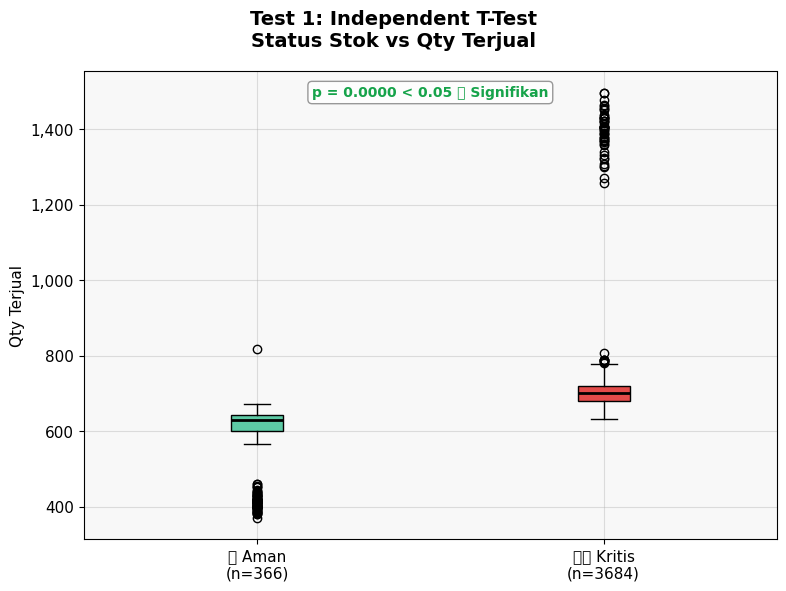

In [ ]:
from scipy import stats

print("=" * 60)
print("A/B TESTING — VALIDASI FITUR FEATURE ENGINEERING")
print("=" * 60)

# ============================================================
# TEST 1 — INDEPENDENT T-TEST
# Hipotesis: Apakah qty terjual berbeda antara bulan dengan
# stok aman vs bulan dengan stok kritis (perlu restock/habis)?
# ============================================================
print("=" * 60)
print("TEST 1: Independent T-Test — Status Stok vs Qty Terjual")
print("=" * 60)

grup_aman   = df_fe[df_fe['Status_Stok'] == '🟢 Aman']['Qty_Sold']
grup_kritis = df_fe[df_fe['Status_Stok'].isin(['🟡 Perlu Restock', '🔴 Habis'])]['Qty_Sold']

t_stat, p_value = stats.ttest_ind(grup_aman, grup_kritis, equal_var=False)
alpha = 0.05

print(f"\n  H0 : Tidak ada perbedaan rata-rata Qty_Sold antara stok aman vs kritis")
print(f"  H1 : Ada perbedaan rata-rata Qty_Sold antara stok aman vs kritis")
print(f"\n  Rata-rata Qty_Sold — Stok Aman   : {grup_aman.mean():.2f} (n={len(grup_aman)})")
print(f"  Rata-rata Qty_Sold — Stok Kritis : {grup_kritis.mean():.2f} (n={len(grup_kritis)})")
print(f"\n  T-Statistic : {t_stat:.4f}")
print(f"  P-Value     : {p_value:.6f}")
print(f"  Alpha       : {alpha}")

if p_value < alpha:
    print(f"\n  ✅ KESIMPULAN: Tolak H0 (p={p_value:.6f} < {alpha})")
    print(f"  → Ada perbedaan signifikan! Stok kritis terjadi saat demand TINGGI.")
    print(f"  → Fitur 'Status_Stok' & 'Discount_Rate' PENTING untuk model prediksi.")
else:
    print(f"\n  ❌ KESIMPULAN: Gagal tolak H0 (p={p_value:.6f} >= {alpha})")
    print(f"  → Tidak ada perbedaan signifikan antar grup.")

# ============================================================
# VISUALISASI TEST 1
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Test 1: Independent T-Test\nStatus Stok vs Qty Terjual',
             fontsize=14, fontweight='bold')

data_plot   = [grup_aman.values, grup_kritis.values]
labels_plot = [f'🟢 Aman\n(n={len(grup_aman)})', f'🔴🟡 Kritis\n(n={len(grup_kritis)})']
bp = ax.boxplot(data_plot, labels=labels_plot, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#5DCAA5')
bp['boxes'][1].set_facecolor('#E24B4A')

ax.set_ylabel('Qty Terjual')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

result1 = f"p = {p_value:.4f} {'< 0.05 ✅ Signifikan' if p_value < alpha else '>= 0.05 ❌ Tidak Signifikan'}"
ax.text(0.5, 0.97, result1, transform=ax.transAxes,
        ha='center', va='top', fontsize=10,
        color='#16A34A' if p_value < alpha else '#DC2626',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.savefig('ab_testing_test1.png', dpi=150, bbox_inches='tight')
plt.show()

Berdasarkan hasil uji T-Test, rata-rata Qty_Sold saat stok aman
adalah 585 unit (n=366), sedangkan saat stok kritis mencapai
709 unit (n=3.684). Dengan T-Statistic -24.55 dan p-value 0.000000
yang jauh di bawah alpha 0.05, maka H0 ditolak — artinya
perbedaan ini terbukti signifikan secara statistik, bukan
terjadi secara kebetulan.

Dari boxplot terlihat bahwa distribusi stok kritis jauh lebih
tinggi dan lebih lebar dibanding stok aman, bahkan terdapat
outlier ekstrem di atas 1.400 unit. Ini menunjukkan bahwa
pada bulan-bulan tertentu permintaan melonjak sangat tinggi
hingga jauh melampaui rata-rata, yang langsung membuat kondisi
stok menjadi kritis.

Kesimpulannya, stok kritis bukan disebabkan oleh manajemen
yang buruk, melainkan karena demand yang sedang tinggi membuat
stok cepat habis. Hal ini membuktikan bahwa fitur Status_Stok
dan Discount_Rate yang dibuat di Feature Engineering benar-benar
mencerminkan pola penjualan yang nyata, sehingga layak dan
penting untuk digunakan sebagai fitur dalam model prediksi.
""")

Test 2 — ANOVA: Apakah rata-rata penjualan berbeda signifikan antar Quarter?

TEST 2: One-Way ANOVA — Quarter vs Qty Terjual

  H0 : Rata-rata Qty_Sold sama di semua quarter (Q1=Q2=Q3=Q4)
  H1 : Minimal satu quarter memiliki rata-rata Qty_Sold yang berbeda

  Rata-rata per Quarter:
    Q1 : 698.22 (n=972)
    Q2 : 680.21 (n=1134)
    Q3 : 708.41 (n=972)
    Q4 : 710.56 (n=972)

  F-Statistic : 24.5951
  P-Value     : 0.000000
  Alpha       : 0.05

  ✅ KESIMPULAN: Tolak H0 (p=0.000000 < 0.05)
  → Ada perbedaan signifikan antar quarter!
  → Fitur 'Quarter' & 'Month' PENTING untuk model prediksi.


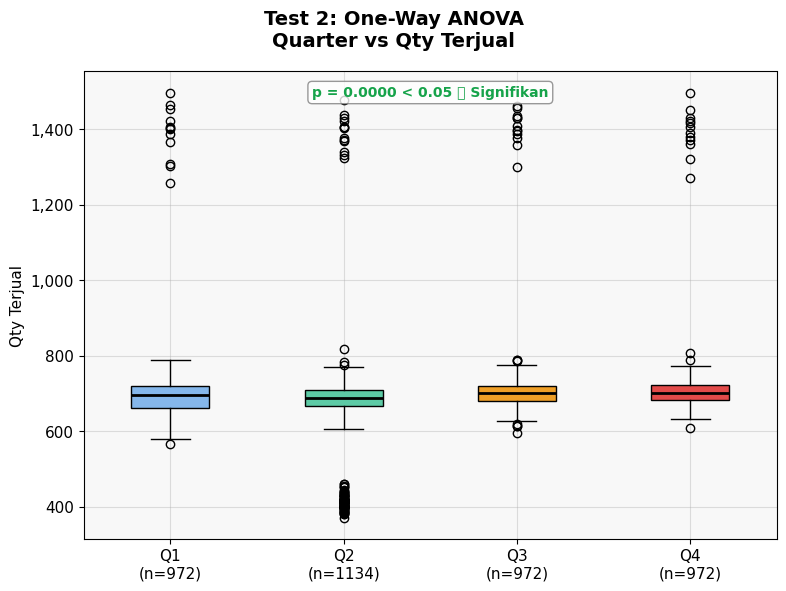

In [ ]:
from scipy import stats

# ============================================================
# TEST 2 — ONE-WAY ANOVA
# Hipotesis: Apakah rata-rata qty terjual berbeda antar quarter?
# ============================================================
print("=" * 60)
print("TEST 2: One-Way ANOVA — Quarter vs Qty Terjual")
print("=" * 60)

q1 = df_fe[df_fe['Quarter'] == 1]['Qty_Sold']
q2 = df_fe[df_fe['Quarter'] == 2]['Qty_Sold']
q3 = df_fe[df_fe['Quarter'] == 3]['Qty_Sold']
q4 = df_fe[df_fe['Quarter'] == 4]['Qty_Sold']

f_stat, p_anova = stats.f_oneway(q1, q2, q3, q4)
alpha = 0.05

print(f"\n  H0 : Rata-rata Qty_Sold sama di semua quarter (Q1=Q2=Q3=Q4)")
print(f"  H1 : Minimal satu quarter memiliki rata-rata Qty_Sold yang berbeda")
print(f"\n  Rata-rata per Quarter:")
for q, label in zip([q1, q2, q3, q4], ['Q1', 'Q2', 'Q3', 'Q4']):
    print(f"    {label} : {q.mean():.2f} (n={len(q)})")
print(f"\n  F-Statistic : {f_stat:.4f}")
print(f"  P-Value     : {p_anova:.6f}")
print(f"  Alpha       : {alpha}")

if p_anova < alpha:
    print(f"\n  ✅ KESIMPULAN: Tolak H0 (p={p_anova:.6f} < {alpha})")
    print(f"  → Ada perbedaan signifikan antar quarter!")
    print(f"  → Fitur 'Quarter' & 'Month' PENTING untuk model prediksi.")
else:
    print(f"\n  ❌ KESIMPULAN: Gagal tolak H0 (p={p_anova:.6f} >= {alpha})")
    print(f"  → Tidak ada perbedaan signifikan antar quarter.")

# ============================================================
# VISUALISASI TEST 2
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Test 2: One-Way ANOVA\nQuarter vs Qty Terjual',
             fontsize=14, fontweight='bold')

data_anova   = [q1.values, q2.values, q3.values, q4.values]
labels_anova = [f'Q1\n(n={len(q1)})', f'Q2\n(n={len(q2)})',
                f'Q3\n(n={len(q3)})', f'Q4\n(n={len(q4)})']
bp2 = ax.boxplot(data_anova, labels=labels_anova, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))

anova_colors = ['#85B7EB', '#5DCAA5', '#EF9F27', '#E24B4A']
for patch, color in zip(bp2['boxes'], anova_colors):
    patch.set_facecolor(color)

ax.set_ylabel('Qty Terjual')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

result2 = f"p = {p_anova:.4f} {'< 0.05 ✅ Signifikan' if p_anova < alpha else '>= 0.05 ❌ Tidak Signifikan'}"
ax.text(0.5, 0.97, result2, transform=ax.transAxes,
        ha='center', va='top', fontsize=10,
        color='#16A34A' if p_anova < alpha else '#DC2626',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.savefig('ab_testing_test2.png', dpi=150, bbox_inches='tight')
plt.show()

Berdasarkan hasil uji ANOVA, rata-rata Qty_Sold per quarter
adalah Q1: 698 unit, Q2: 680 unit, Q3: 708 unit, dan Q4: 710
unit. Dengan F-Statistic 24.60 dan p-value 0.000000 yang jauh
di bawah alpha 0.05, maka H0 ditolak — artinya minimal ada
satu quarter yang pola penjualannya berbeda secara signifikan
dari quarter lainnya.

Dari boxplot terlihat bahwa Q2 memiliki rata-rata terendah
(680 unit) sekaligus distribusi yang paling sempit, namun
memiliki outlier ekstrem di bawah 400 unit yang tidak muncul
di quarter lain. Sebaliknya, Q3 dan Q4 konsisten berada di
posisi tertinggi (708-710 unit) dengan distribusi yang lebih
stabil, menunjukkan bahwa penjualan cenderung memuncak di
pertengahan hingga akhir tahun.

Kesimpulannya, pola penjualan memang berubah-ubah tergantung
quarter — Q4 adalah puncak penjualan, sementara Q2 adalah
titik terendah dengan risiko penjualan sangat rendah yang
lebih tinggi. Hal ini membuktikan bahwa fitur Quarter dan
Month yang dibuat di Feature Engineering benar-benar
mencerminkan pola musiman yang nyata, sehingga penting
untuk dimasukkan ke dalam model prediksi demand.
""")